# **Praktikum Mandiri 11 | ML Senin Pagi**

Nama : Rika Rahma

NIM : 0110222134

Rombel : TI08 - 2022

1. Import Library

In [41]:
!pip install geopandas folium contextily shapely scikit-learn kneed

In [42]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10,6)

2. Loading Dataset

In [43]:
# Menghubungkan colab dengan Google Drive
from google.colab import drive
drive.mount ('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [44]:
# Memanggil dataset lewat Gdrive
path = '/content/gdrive/MyDrive/Praktikum_ML/praktikum11/data/'

In [45]:
import pandas as pd

# Membaca file CSV menggunakan pandas
df = pd.read_csv('/content/gdrive/MyDrive/Praktikum_ML/praktikum11/data/Earthquake.csv')

In [46]:
# Cetak header data (5 baris data) dari file
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [47]:
# Menampilkan informasi detail dengan df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [48]:
# Cek Missing Value
df.isnull().sum()

,0
Date,0
Time,0
Latitude,0
Longitude,0
Type,0
Depth,0
Depth Error,18951
Depth Seismic Stations,16315
Magnitude,0
Magnitude Type,3


In [49]:
# Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [50]:
# Menampilkan statistika deskriptif dari dataset
df.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


3. Standarisasi Kolom

In [51]:
# Standarisasi nama kolom (lower-case) agar konsisten
df.columns = df.columns.str.lower()

In [52]:
# Tampilkan kolom
print("Kolom:", df.columns.tolist())

Kolom: ['date', 'time', 'latitude', 'longitude', 'type', 'depth', 'depth error', 'depth seismic stations', 'magnitude', 'magnitude type', 'magnitude error', 'magnitude seismic stations', 'azimuthal gap', 'horizontal distance', 'horizontal error', 'root mean square', 'id', 'source', 'location source', 'magnitude source', 'status']


4. Drop rows tanpa koordinat / magnitudo

In [53]:
# Drop rows tanpa koordinat / magnitudo
df = df.dropna(subset=['latitude','longitude','magnitude'])
df = df.drop_duplicates()
print("Shape setelah clean:", df.shape)

Shape setelah clean: (23412, 21)


5. Sampling Dataset

In [54]:
# Sampling dataset
# datanya sangat banyak (ratusan ribu)
MAX_SAMPLE = 50000
if df.shape[0] > MAX_SAMPLE:
    df = df.sample(MAX_SAMPLE, random_state=42).reset_index(drop=True)
    print("Sampling menjadi:", df.shape)

6. Exploratory Spatial Data Analysis — Heatmap (Folium)

In [68]:
# Exploratory Spatial Data Analysis — Heatmap (Folium)
import folium
from folium.plugins import HeatMap

# Buat peta
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()],
               zoom_start=2, tiles='OpenStreetMap')

# Tambah heatmap
heat_data = df[['latitude', 'longitude']].values.tolist()
HeatMap(heat_data, radius=8, blur=15).add_to(m)

# TAMPILKAN PETANYA
m

7. Sebaran Global Earthquake

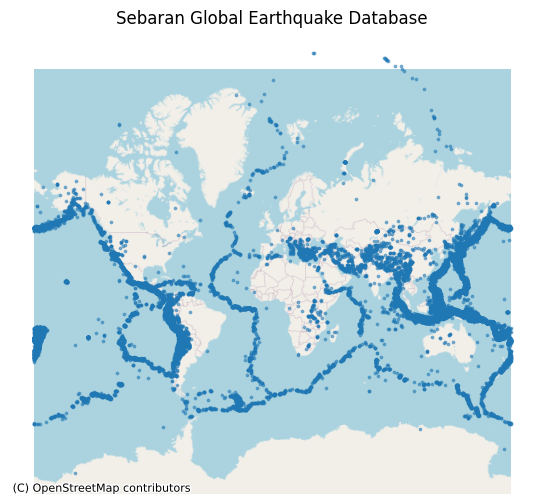

In [56]:
# 7. Sebaran Titik Gempa di Peta (GeoPandas + Basemap)
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

ax = gdf.plot(markersize=3, alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
plt.title("Sebaran Global Earthquake Database")
plt.show()

8. Clustering

In [57]:
# Pilih fitur untuk clustering
features = ['latitude','longitude','magnitude']   # bisa ditambah 'depth' jika tersedia
X = df[features].copy()
print("Features:\n", X.head())

Features:
    latitude  longitude  magnitude
0    19.246    145.616        6.0
1     1.863    127.352        5.8
2   -20.579   -173.972        6.2
3   -59.076    -23.557        5.8
4    11.938    126.427        5.8


In [58]:
features = ["latitude", "longitude", "magnitude", "depth"]

9. Scaling Fitur

In [59]:
# Scaling fitur (RobustScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

10. Tuning eps

In [60]:
# Tuning eps untuk Cari Nilai Terbaik
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

eps_values = np.arange(0.05, 0.55, 0.05)   # 0.05 → 0.50
min_samples = 5

best_score = -1
best_eps = None
scores = {}

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    # Hitung silhouette tanpa noise (-1)
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        scores[eps] = score

        if score > best_score:
            best_score = score
            best_eps = eps

best_eps, best_score, scores

(np.float64(0.45),
 np.float64(0.6513524181079859),
 {np.float64(0.05): np.float64(0.019346167362130014),
  np.float64(0.1): np.float64(-0.11093519053335671),
  np.float64(0.15000000000000002): np.float64(-0.2568194941100262),
  np.float64(0.2): np.float64(-0.08142331822791993),
  np.float64(0.25): np.float64(-0.04693220212567112),
  np.float64(0.3): np.float64(0.26223181096301),
  np.float64(0.35000000000000003): np.float64(0.26871018080907233),
  np.float64(0.4): np.float64(0.2730189838671847),
  np.float64(0.45): np.float64(0.6513524181079859),
  np.float64(0.5): np.float64(0.6506033676496634)})

11. K-Distance Graph

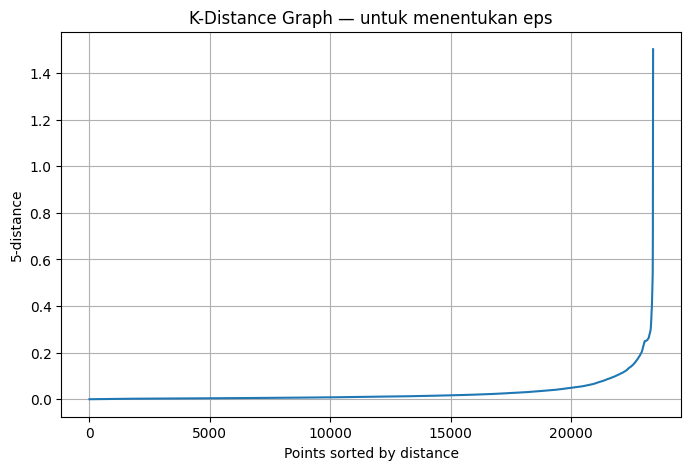

In [61]:
# K-Distance Graph untuk tentukan eps
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples)
nn_fit = nn.fit(X_scaled)
distances, indices = nn_fit.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_dist)
plt.ylabel(f'{min_samples}-distance')
plt.xlabel('Points sorted by distance')
plt.title('K-Distance Graph — untuk menentukan eps')
plt.grid(True)
plt.show()

In [62]:
# Deteksi elbow otomatis
kl = KneeLocator(range(len(k_dist)), k_dist, curve='convex', direction='increasing')
elbow = kl.knee
print("Elbow index:", elbow)
if elbow:
    eps_suggest = k_dist[elbow]
    print("Suggested eps:", eps_suggest)

Elbow index: 23346
Suggested eps: 0.3719375692927801


12. DBSCAN

In [63]:
# Jalankan DBSCAN
eps_value = 0.45
min_samples = 5

db = DBSCAN(eps=eps_value, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

df['cluster'] = labels

# Hitung silhouette final
mask = df['cluster'] != -1
sil = silhouette_score(X_scaled[mask], labels[mask])
sil

np.float64(0.6513524181079859)

13. Silhouette

In [64]:
# Evaluasi cluster (Silhouette)
mask = df['cluster'] != -1
if df['cluster'][mask].nunique() > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette Score (tanpa noise):", round(sil,4))
else:
    print("Tidak cukup cluster untuk hitung Silhouette (kemungkinan 1 cluster atau semua noise).")


Silhouette Score (tanpa noise): 0.6514


14. Peta Sebar Cluster

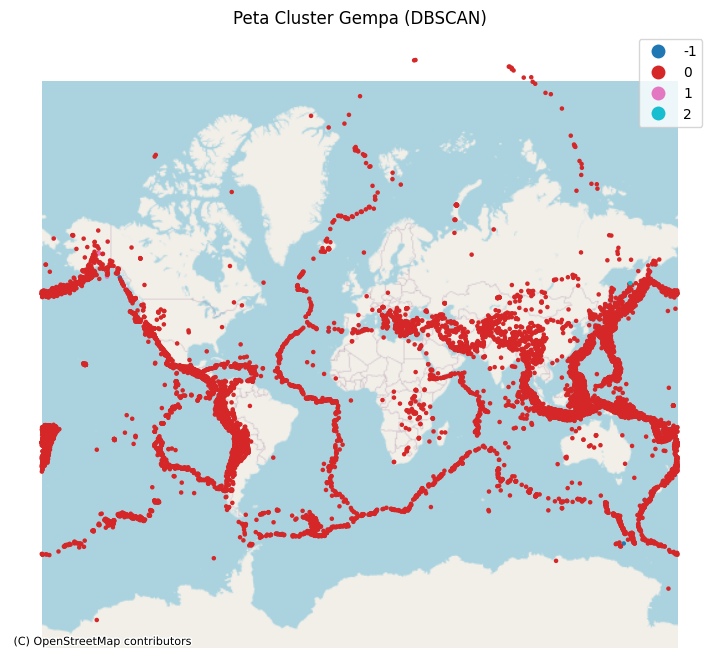

In [65]:
# Peta sebar cluster (GeoPandas + Basemap)
gdf2 = gdf.copy()
gdf2['cluster'] = df['cluster'].values
fig, ax = plt.subplots(figsize=(12,8))
gdf2.plot(column='cluster', categorical=True, legend=True, markersize=5, ax=ax)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
plt.title("Peta Cluster Gempa (DBSCAN)")
plt.show()

15. Ringkasan Statistik

In [66]:
# Ringkasan statistik tiap cluster
cluster_summary = df.groupby('cluster')[features].mean().round(3)
cluster_counts = df['cluster'].value_counts().sort_index()
print("Jumlah tiap cluster:\n", cluster_counts)
display(cluster_summary)

Jumlah tiap cluster:
 cluster
-1       24
 0    23375
 1        7
 2        6
Name: count, dtype: int64


,latitude,longitude,magnitude,depth
cluster,,,,
-1,-11.542,22.055,8.162,24.115
0,1.665,39.688,5.879,70.819
1,55.430,-155.073,7.871,21.414
2,45.696,149.280,8.250,114.833
